# Churn Prediction Modeling

## Customer Intelligence Analytics

This notebook trains and evaluates machine-learning models to predict whether
an active customer will make no purchase during the following 90 days.

The modeling strategy preserves chronological order and uses purged temporal
gaps between training, validation, and test periods.

### Modeling principles

- No random train-test splitting.
- No future-derived features.
- Model selection is performed using validation data only.
- Classification thresholds are selected using validation data only.
- The final test period is used once for unbiased evaluation.
- Ranking quality, classification performance, calibration, and business lift
  are evaluated separately.

In [89]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
)

from sklearn.calibration import calibration_curve


pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


RANDOM_STATE = 42


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent


DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "churn_snapshots.parquet"
)

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


print(f"Input data: {DATA_PATH}")

Input data: c:\Users\omary\Documents\VS Code\customer-intelligence-analytics\data\processed\churn_snapshots.parquet


In [90]:
churn_data = pd.read_parquet(DATA_PATH)


date_columns = [
    "snapshot_date",
    "prediction_end_date",
    "first_purchase",
    "last_purchase",
]


for column in date_columns:
    churn_data[column] = pd.to_datetime(
        churn_data[column]
    )


print(f"Rows:              {len(churn_data):,}")
print(
    f"Unique customers:  "
    f"{churn_data['customer_id'].nunique():,}"
)
print(
    f"Snapshots:         "
    f"{churn_data['snapshot_date'].nunique():,}"
)
print(
    f"Overall churn:     "
    f"{churn_data['churn_90d'].mean() * 100:.2f}%"
)

Rows:              48,079
Unique customers:  5,236
Snapshots:         16
Overall churn:     50.94%


## Temporal Train / Validation / Test Design

The 90-day prediction horizon creates a risk of overlap between adjacent
snapshots.

To reduce this temporal leakage, several snapshots are deliberately excluded
between modeling periods.

- **Training:** June 2010 through January 2011
- **Purged gap:** February through April 2011
- **Validation:** May and June 2011
- **Purged gap:** July and August 2011
- **Test:** September 2011

The test period remains untouched during model and threshold selection.

In [91]:
TRAIN_END = pd.Timestamp("2011-01-01")

VALIDATION_START = pd.Timestamp("2011-05-01")
VALIDATION_END = pd.Timestamp("2011-06-01")

TEST_DATE = pd.Timestamp("2011-09-01")


train_data = churn_data.loc[
    churn_data["snapshot_date"] <= TRAIN_END
].copy()


validation_data = churn_data.loc[
    churn_data["snapshot_date"].between(
        VALIDATION_START,
        VALIDATION_END,
    )
].copy()


test_data = churn_data.loc[
    churn_data["snapshot_date"] == TEST_DATE
].copy()


used_mask = (
    churn_data.index.isin(train_data.index)
    | churn_data.index.isin(validation_data.index)
    | churn_data.index.isin(test_data.index)
)


purged_data = churn_data.loc[
    ~used_mask
].copy()


split_summary = pd.DataFrame(
    {
        "split": [
            "Train",
            "Purged / unused",
            "Validation",
            "Test",
        ],
        "rows": [
            len(train_data),
            len(purged_data),
            len(validation_data),
            len(test_data),
        ],
        "customers": [
            train_data["customer_id"].nunique(),
            purged_data["customer_id"].nunique(),
            validation_data["customer_id"].nunique(),
            test_data["customer_id"].nunique(),
        ],
        "churn_rate_pct": [
            train_data["churn_90d"].mean() * 100,
            purged_data["churn_90d"].mean() * 100,
            validation_data["churn_90d"].mean() * 100,
            test_data["churn_90d"].mean() * 100,
        ],
        "first_snapshot": [
            train_data["snapshot_date"].min(),
            purged_data["snapshot_date"].min(),
            validation_data["snapshot_date"].min(),
            test_data["snapshot_date"].min(),
        ],
        "last_snapshot": [
            train_data["snapshot_date"].max(),
            purged_data["snapshot_date"].max(),
            validation_data["snapshot_date"].max(),
            test_data["snapshot_date"].max(),
        ],
    }
)


display(split_summary)

,split,rows,customers,churn_rate_pct,first_snapshot,last_snapshot
0,Train,24092,4326,50.3611,2010-06-01,2011-01-01
1,Purged / unused,15507,4322,53.8595,2011-02-01,2011-08-01
2,Validation,5708,3271,51.0862,2011-05-01,2011-06-01
3,Test,2772,2772,39.2857,2011-09-01,2011-09-01


In [92]:
assert (
    train_data["prediction_end_date"].max()
    <= VALIDATION_START
)

assert (
    validation_data["prediction_end_date"].max()
    <= TEST_DATE
)

assert (
    train_data["snapshot_date"].max()
    < validation_data["snapshot_date"].min()
)

assert (
    validation_data["snapshot_date"].max()
    < test_data["snapshot_date"].min()
)


print("Temporal split and purge checks passed successfully.")

Temporal split and purge checks passed successfully.


In [93]:
def add_calendar_features(
    dataframe: pd.DataFrame,
) -> pd.DataFrame:
    """Add point-in-time cyclical calendar features."""

    result = dataframe.copy()

    month = result["snapshot_date"].dt.month

    result["snapshot_month_sin"] = np.sin(
        2 * np.pi * month / 12
    )

    result["snapshot_month_cos"] = np.cos(
        2 * np.pi * month / 12
    )

    return result


train_data = add_calendar_features(train_data)
validation_data = add_calendar_features(validation_data)
test_data = add_calendar_features(test_data)

## Predictive Features

Only information available at the snapshot date is used.

Future order count, future revenue, churn labels, customer identifiers, and
calendar dates themselves are excluded from model inputs.

RFM and full-dataset machine-learning segment labels are also excluded because
they were created using data beyond historical prediction dates.

In [94]:
FEATURE_COLUMNS = [
    # Lifetime behavior
    "recency_days",
    "frequency",
    "monetary",
    "total_units",
    "unique_products",
    "customer_age_days",
    "tenure_days",
    "average_order_value",
    "average_days_between_orders",
    "purchase_rate_per_90d",

    # Recent activity
    "last_30d_orders",
    "last_30d_revenue",
    "last_30d_units",
    "last_90d_orders",
    "last_90d_revenue",
    "last_90d_units",

    # Previous-period behavior
    "previous_90d_orders",
    "previous_90d_revenue",
    "previous_90d_units",

    # Behavioral change
    "orders_change_90d",
    "revenue_change_90d",
    "revenue_change_ratio_90d",

    # Return behavior
    "total_activity_invoices",
    "return_invoices",
    "return_invoice_rate",
    "return_invoices_last_90d",

    # Seasonality
    "snapshot_month_sin",
    "snapshot_month_cos",
]


TARGET = "churn_90d"


X_train = train_data[FEATURE_COLUMNS].copy()
y_train = train_data[TARGET].copy()

X_validation = validation_data[FEATURE_COLUMNS].copy()
y_validation = validation_data[TARGET].copy()

X_test = test_data[FEATURE_COLUMNS].copy()
y_test = test_data[TARGET].copy()


print(f"Features:         {len(FEATURE_COLUMNS)}")
print(f"Training rows:    {len(X_train):,}")
print(f"Validation rows:  {len(X_validation):,}")
print(f"Test rows:        {len(X_test):,}")

Features:         28
Training rows:    24,092
Validation rows:  5,708
Test rows:        2,772


In [95]:
for name, X, y in [
    ("train", X_train, y_train),
    ("validation", X_validation, y_validation),
    ("test", X_test, y_test),
]:

    assert not X.isna().any().any()

    assert np.isfinite(
        X.to_numpy(dtype="float64")
    ).all()

    assert y.isin([0, 1]).all()

    print(
        f"{name:10s} | "
        f"rows={len(X):,} | "
        f"churn={y.mean() * 100:.2f}%"
    )

train      | rows=24,092 | churn=50.36%
validation | rows=5,708 | churn=51.09%
test       | rows=2,772 | churn=39.29%


In [96]:
models = {
    "Dummy Baseline": DummyClassifier(
        strategy="prior",
    ),

    "Logistic Regression": Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=10,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    ),
}

In [97]:
models = {
    "Dummy Baseline": DummyClassifier(
        strategy="prior",
    ),

    "Logistic Regression": Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=10,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    ),
}

In [98]:
def evaluate_probability_predictions(
    y_true: pd.Series,
    probabilities: np.ndarray,
) -> dict[str, float]:

    return {
        "roc_auc": roc_auc_score(
            y_true,
            probabilities,
        ),

        "pr_auc": average_precision_score(
            y_true,
            probabilities,
        ),

        "brier_score": brier_score_loss(
            y_true,
            probabilities,
        ),
    }

In [99]:
validation_results = []

fitted_models = {}

validation_probabilities = {}


for model_name, model in models.items():

    print(f"Training: {model_name}")

    model.fit(
        X_train,
        y_train,
    )

    probabilities = model.predict_proba(
        X_validation
    )[:, 1]

    metrics = evaluate_probability_predictions(
        y_validation,
        probabilities,
    )

    validation_results.append(
        {
            "model": model_name,
            **metrics,
        }
    )

    fitted_models[model_name] = model

    validation_probabilities[
        model_name
    ] = probabilities


validation_results = pd.DataFrame(
    validation_results
).sort_values(
    "pr_auc",
    ascending=False,
).reset_index(drop=True)


display(validation_results)

Training: Dummy Baseline
Training: Logistic Regression
Training: Random Forest
Training: HistGradientBoosting


,model,roc_auc,pr_auc,brier_score
0,Random Forest,0.7692,0.7351,0.1995
1,Logistic Regression,0.7425,0.7293,0.2171
2,HistGradientBoosting,0.7542,0.7247,0.2183
3,Dummy Baseline,0.5000,0.5109,0.2499


In [100]:
def lift_at_fraction(
    y_true: pd.Series,
    probabilities: np.ndarray,
    fraction: float,
) -> dict[str, float]:

    results = pd.DataFrame(
        {
            "target": np.asarray(y_true),
            "probability": probabilities,
        }
    ).sort_values(
        "probability",
        ascending=False,
    )

    top_n = max(
        1,
        int(
            np.ceil(
                len(results)
                * fraction
            )
        ),
    )

    selected = results.head(top_n)

    baseline_rate = results["target"].mean()

    selected_rate = selected["target"].mean()

    captured_churners = (
        selected["target"].sum()
        / results["target"].sum()
    )

    return {
        "selected_customers": top_n,
        "selected_churn_rate": selected_rate,
        "lift": (
            selected_rate
            / baseline_rate
        ),
        "recall_at_k": captured_churners,
    }

In [101]:
lift_results = []


for model_name, probabilities in (
    validation_probabilities.items()
):

    for fraction in [
        0.05,
        0.10,
        0.20,
    ]:

        metrics = lift_at_fraction(
            y_true=y_validation,
            probabilities=probabilities,
            fraction=fraction,
        )

        lift_results.append(
            {
                "model": model_name,
                "top_fraction": fraction,
                **metrics,
            }
        )


lift_results = pd.DataFrame(
    lift_results
)


display(lift_results)

,model,top_fraction,selected_customers,selected_churn_rate,lift,recall_at_k
0,Dummy Baseline,0.0500,286,0.5000,0.9787,0.0490
1,Dummy Baseline,0.1000,571,0.5044,0.9873,0.0988
2,Dummy Baseline,0.2000,1142,0.5070,0.9925,0.1986
3,Logistic Regression,0.0500,286,0.8811,1.7248,0.0864
4,Logistic Regression,0.1000,571,0.8214,1.6078,0.1608
5,Logistic Regression,0.2000,1142,0.7750,1.5170,0.3035
6,Random Forest,0.0500,286,0.8112,1.5879,0.0796
7,Random Forest,0.1000,571,0.8056,1.5770,0.1578
8,Random Forest,0.2000,1142,0.7837,1.5341,0.3069
9,HistGradientBoosting,0.0500,286,0.8007,1.5673,0.0785


In [102]:
lift_pivot = lift_results.pivot(
    index="model",
    columns="top_fraction",
    values="lift",
)


lift_pivot.columns = [
    f"lift_top_{int(value * 100)}pct"
    for value in lift_pivot.columns
]


display(
    lift_pivot.sort_values(
        "lift_top_10pct",
        ascending=False,
    )
)

,lift_top_5pct,lift_top_10pct,lift_top_20pct
model,,,
Logistic Regression,1.7248,1.6078,1.5170
HistGradientBoosting,1.5673,1.5941,1.5272
Random Forest,1.5879,1.5770,1.5341
Dummy Baseline,0.9787,0.9873,0.9925


In [103]:
model_comparison = (
    validation_results
    .merge(
        lift_pivot.reset_index(),
        on="model",
        how="left",
    )
    .sort_values(
        [
            "pr_auc",
            "roc_auc",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)


display(model_comparison)

,model,roc_auc,pr_auc,brier_score,lift_top_5pct,lift_top_10pct,lift_top_20pct
0,Random Forest,0.7692,0.7351,0.1995,1.5879,1.5770,1.5341
1,Logistic Regression,0.7425,0.7293,0.2171,1.7248,1.6078,1.5170
2,HistGradientBoosting,0.7542,0.7247,0.2183,1.5673,1.5941,1.5272
3,Dummy Baseline,0.5000,0.5109,0.2499,0.9787,0.9873,0.9925


## Model Selection

Random Forest was selected as the primary churn model based on validation
performance.

It achieved the strongest overall ranking performance:

- ROC-AUC: 0.7692
- PR-AUC: 0.7351
- Brier Score: 0.1995

It outperformed the other candidate models in both ROC-AUC and PR-AUC while
also producing the lowest Brier Score, indicating better probability quality.

Logistic Regression achieved slightly stronger lift among the top 5% and 10%
of ranked customers. This makes it a useful interpretable challenger model,
particularly for highly constrained retention budgets.

However, Random Forest provides the strongest overall balance of ranking
quality, probability accuracy, and broader customer targeting performance and
is therefore selected as the primary model.

In [104]:
SELECTED_MODEL_NAME = "Random Forest"

selected_model = fitted_models[
    SELECTED_MODEL_NAME
]

validation_probs = validation_probabilities[
    SELECTED_MODEL_NAME
]


threshold_results = []


for threshold in np.arange(
    0.05,
    0.951,
    0.01,
):

    predictions = (
        validation_probs >= threshold
    ).astype(int)

    threshold_results.append(
        {
            "threshold": threshold,

            "precision": precision_score(
                y_validation,
                predictions,
                zero_division=0,
            ),

            "recall": recall_score(
                y_validation,
                predictions,
                zero_division=0,
            ),

            "f1": f1_score(
                y_validation,
                predictions,
                zero_division=0,
            ),

            "accuracy": accuracy_score(
                y_validation,
                predictions,
            ),

            "balanced_accuracy": (
                balanced_accuracy_score(
                    y_validation,
                    predictions,
                )
            ),

            "predicted_positive_rate": (
                predictions.mean()
            ),
        }
    )


threshold_evaluation = pd.DataFrame(
    threshold_results
)


display(
    threshold_evaluation.sort_values(
        "f1",
        ascending=False,
    ).head(15)
)

,threshold,precision,recall,f1,accuracy,balanced_accuracy,predicted_positive_rate
26,0.3100,0.6290,0.9194,0.7470,0.6819,0.6766,0.7467
28,0.3300,0.6390,0.8978,0.7466,0.6887,0.6840,0.7178
27,0.3200,0.6326,0.9088,0.7460,0.6838,0.6788,0.7339
29,0.3400,0.6442,0.8848,0.7456,0.6915,0.6872,0.7016
25,0.3000,0.6231,0.9259,0.7449,0.6761,0.6705,0.7591
24,0.2900,0.6175,0.9335,0.7433,0.6706,0.6648,0.7722
23,0.2800,0.6137,0.9410,0.7429,0.6673,0.6612,0.7833
30,0.3500,0.6477,0.8693,0.7423,0.6917,0.6877,0.6857
31,0.3600,0.6520,0.8567,0.7405,0.6932,0.6896,0.6712
32,0.3700,0.6586,0.8436,0.7397,0.6967,0.6935,0.6543


In [105]:
best_threshold_row = (
    threshold_evaluation
    .sort_values(
        [
            "f1",
            "balanced_accuracy",
        ],
        ascending=False,
    )
    .iloc[0]
)


SELECTED_THRESHOLD = float(
    best_threshold_row["threshold"]
)


print(
    f"Selected threshold: "
    f"{SELECTED_THRESHOLD:.2f}"
)

display(
    best_threshold_row.to_frame(
        name="validation_value"
    )
)

Selected threshold: 0.31


,validation_value
threshold,0.3100
precision,0.6290
recall,0.9194
f1,0.7470
accuracy,0.6819
balanced_accuracy,0.6766
predicted_positive_rate,0.7467


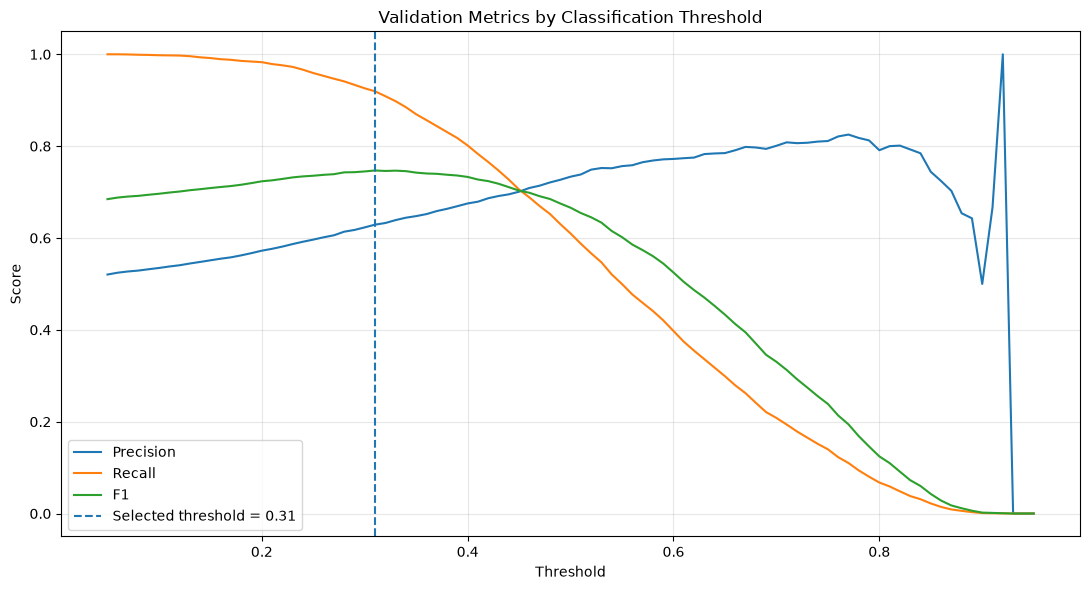

In [106]:
plt.figure(figsize=(11, 6))

plt.plot(
    threshold_evaluation["threshold"],
    threshold_evaluation["precision"],
    label="Precision",
)

plt.plot(
    threshold_evaluation["threshold"],
    threshold_evaluation["recall"],
    label="Recall",
)

plt.plot(
    threshold_evaluation["threshold"],
    threshold_evaluation["f1"],
    label="F1",
)

plt.axvline(
    SELECTED_THRESHOLD,
    linestyle="--",
    label=(
        f"Selected threshold = "
        f"{SELECTED_THRESHOLD:.2f}"
    ),
)

plt.title(
    "Validation Metrics by Classification Threshold"
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "churn_threshold_selection.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [107]:
validation_predictions = (
    validation_probs
    >= SELECTED_THRESHOLD
).astype(int)


validation_confusion = confusion_matrix(
    y_validation,
    validation_predictions,
)


validation_confusion_df = pd.DataFrame(
    validation_confusion,
    index=[
        "Actual Non-Churn",
        "Actual Churn",
    ],
    columns=[
        "Predicted Non-Churn",
        "Predicted Churn",
    ],
)


display(validation_confusion_df)

,Predicted Non-Churn,Predicted Churn
Actual Non-Churn,1211,1581
Actual Churn,235,2681


In [108]:
development_data = pd.concat(
    [
        train_data,
        validation_data,
    ],
    ignore_index=True,
)


X_development = development_data[
    FEATURE_COLUMNS
].copy()

y_development = development_data[
    TARGET
].copy()


print(
    f"Final development rows: "
    f"{len(X_development):,}"
)

print(
    f"Development churn rate: "
    f"{y_development.mean() * 100:.2f}%"
)

Final development rows: 29,800
Development churn rate: 50.50%


In [109]:
final_model = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)


final_model.fit(
    X_development,
    y_development,
)


print(
    "Final Random Forest trained on "
    "training + validation data."
)

Final Random Forest trained on training + validation data.


In [110]:
test_probabilities = (
    final_model.predict_proba(
        X_test
    )[:, 1]
)


test_predictions = (
    test_probabilities
    >= SELECTED_THRESHOLD
).astype(int)

In [111]:
test_metrics = pd.Series(
    {
        "ROC-AUC": roc_auc_score(
            y_test,
            test_probabilities,
        ),

        "PR-AUC": average_precision_score(
            y_test,
            test_probabilities,
        ),

        "Brier Score": brier_score_loss(
            y_test,
            test_probabilities,
        ),

        "Accuracy": accuracy_score(
            y_test,
            test_predictions,
        ),

        "Balanced Accuracy": (
            balanced_accuracy_score(
                y_test,
                test_predictions,
            )
        ),

        "Precision": precision_score(
            y_test,
            test_predictions,
            zero_division=0,
        ),

        "Recall": recall_score(
            y_test,
            test_predictions,
            zero_division=0,
        ),

        "F1": f1_score(
            y_test,
            test_predictions,
            zero_division=0,
        ),

        "Selected Threshold": (
            SELECTED_THRESHOLD
        ),

        "Test Churn Rate": (
            y_test.mean()
        ),

        "Predicted Churn Rate": (
            test_predictions.mean()
        ),
    },
    name="value",
)


display(
    test_metrics.to_frame()
)

,value
ROC-AUC,0.7569
PR-AUC,0.6306
Brier Score,0.1938
Accuracy,0.6302
Balanced Accuracy,0.6764
Precision,0.5170
Recall,0.8916
F1,0.6545
Selected Threshold,0.3100
Test Churn Rate,0.3929


In [112]:
test_confusion = confusion_matrix(
    y_test,
    test_predictions,
)


test_confusion_df = pd.DataFrame(
    test_confusion,
    index=[
        "Actual Non-Churn",
        "Actual Churn",
    ],
    columns=[
        "Predicted Non-Churn",
        "Predicted Churn",
    ],
)


display(test_confusion_df)

,Predicted Non-Churn,Predicted Churn
Actual Non-Churn,776,907
Actual Churn,118,971


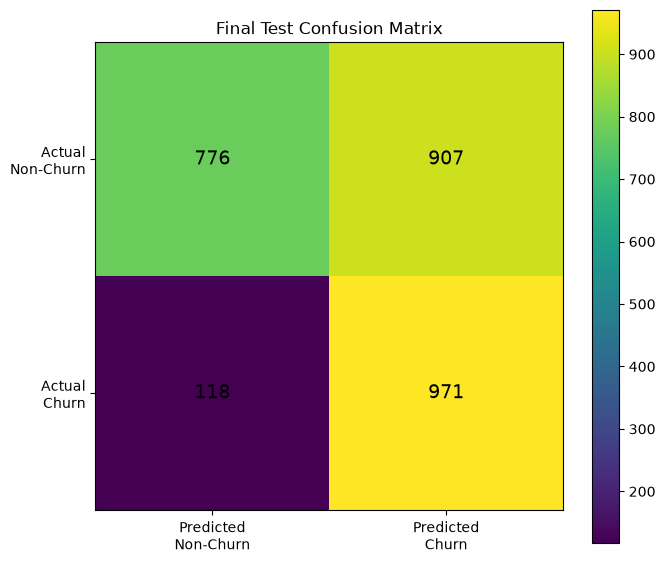

In [113]:
fig, ax = plt.subplots(
    figsize=(7, 6)
)


image = ax.imshow(
    test_confusion
)


ax.set_xticks(
    [0, 1],
    [
        "Predicted\nNon-Churn",
        "Predicted\nChurn",
    ],
)

ax.set_yticks(
    [0, 1],
    [
        "Actual\nNon-Churn",
        "Actual\nChurn",
    ],
)


for row in range(2):
    for column in range(2):

        ax.text(
            column,
            row,
            f"{test_confusion[row, column]:,}",
            ha="center",
            va="center",
            fontsize=14,
        )


plt.title("Final Test Confusion Matrix")
plt.colorbar(image)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "churn_test_confusion_matrix.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

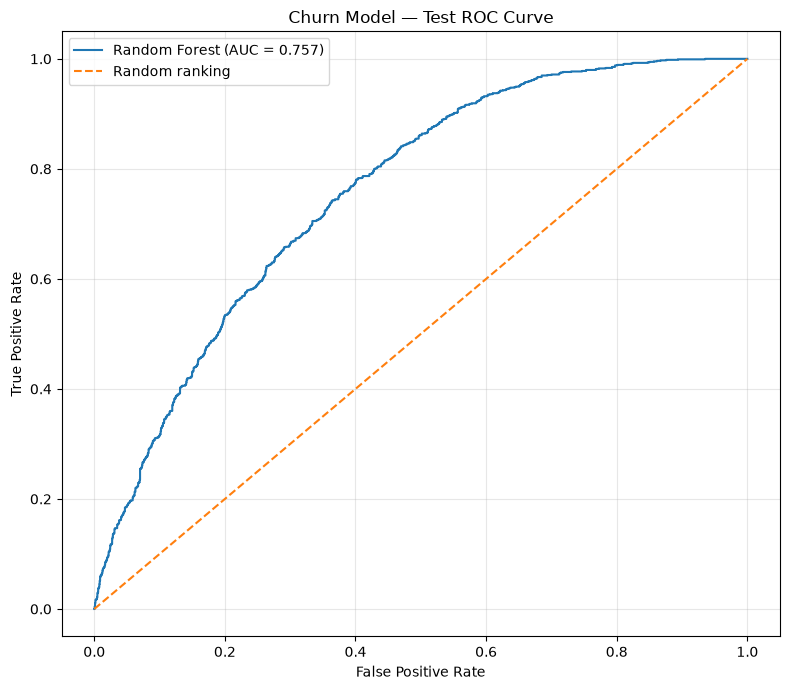

In [114]:
fpr, tpr, _ = roc_curve(
    y_test,
    test_probabilities,
)


test_roc_auc = roc_auc_score(
    y_test,
    test_probabilities,
)


plt.figure(figsize=(8, 7))

plt.plot(
    fpr,
    tpr,
    label=(
        f"Random Forest "
        f"(AUC = {test_roc_auc:.3f})"
    ),
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random ranking",
)

plt.title("Churn Model — Test ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "churn_test_roc_curve.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

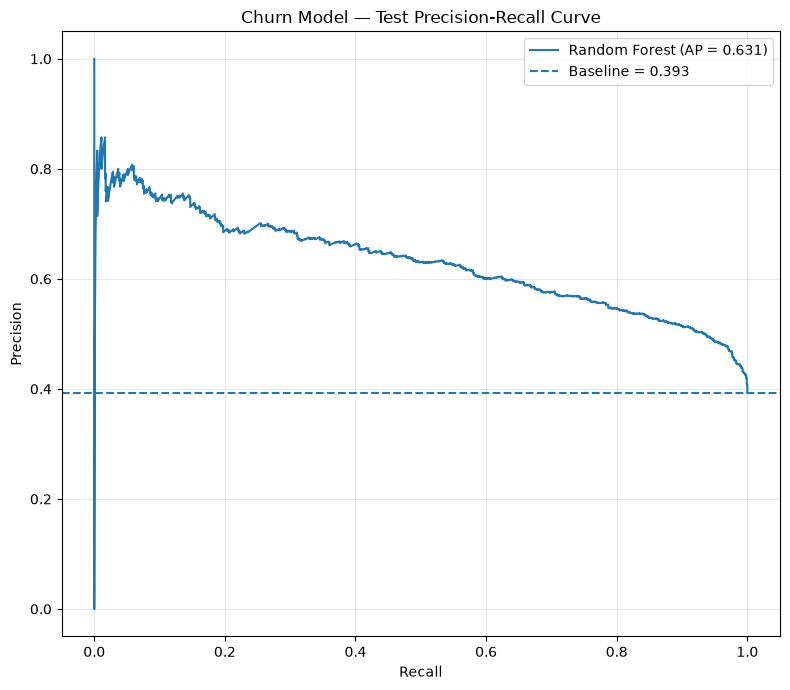

In [115]:
precision_curve, recall_curve, _ = (
    precision_recall_curve(
        y_test,
        test_probabilities,
    )
)


test_pr_auc = average_precision_score(
    y_test,
    test_probabilities,
)


baseline_precision = y_test.mean()


plt.figure(figsize=(8, 7))

plt.plot(
    recall_curve,
    precision_curve,
    label=(
        f"Random Forest "
        f"(AP = {test_pr_auc:.3f})"
    ),
)

plt.axhline(
    baseline_precision,
    linestyle="--",
    label=(
        f"Baseline = "
        f"{baseline_precision:.3f}"
    ),
)


plt.title(
    "Churn Model — Test Precision-Recall Curve"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "churn_test_precision_recall_curve.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [116]:
test_lift_results = []


for fraction in [
    0.05,
    0.10,
    0.20,
]:

    metrics = lift_at_fraction(
        y_true=y_test,
        probabilities=test_probabilities,
        fraction=fraction,
    )

    test_lift_results.append(
        {
            "top_fraction": fraction,
            **metrics,
        }
    )


test_lift_results = pd.DataFrame(
    test_lift_results
)


display(test_lift_results)

,top_fraction,selected_customers,selected_churn_rate,lift,recall_at_k
0,0.0500,139,0.7410,1.8862,0.0946
1,0.1000,278,0.7158,1.8221,0.1827
2,0.2000,555,0.6757,1.7199,0.3444


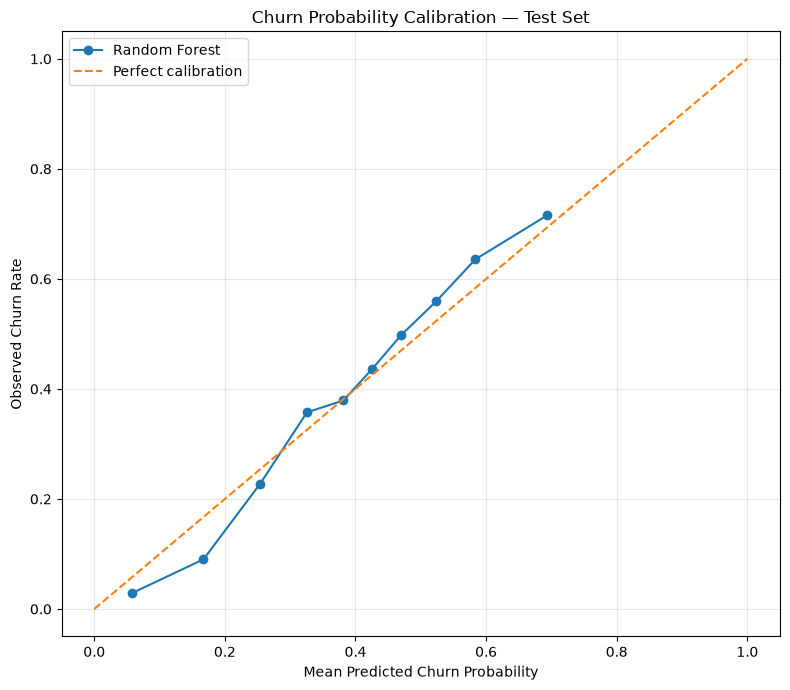

In [117]:
fraction_of_positives, mean_predicted_value = (
    calibration_curve(
        y_test,
        test_probabilities,
        n_bins=10,
        strategy="quantile",
    )
)


plt.figure(figsize=(8, 7))

plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    marker="o",
    label="Random Forest",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)


plt.title(
    "Churn Probability Calibration — Test Set"
)

plt.xlabel("Mean Predicted Churn Probability")
plt.ylabel("Observed Churn Rate")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "churn_test_calibration.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [118]:
feature_importance = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,
        "importance": (
            final_model.feature_importances_
        ),
    }
).sort_values(
    "importance",
    ascending=False,
).reset_index(drop=True)


display(
    feature_importance.head(20)
)

,feature,importance
0,monetary,0.0840
1,total_units,0.0664
2,frequency,0.0660
3,total_activity_invoices,0.0611
4,tenure_days,0.0527
5,purchase_rate_per_90d,0.0509
6,average_days_between_orders,0.0499
7,last_90d_revenue,0.0489
8,unique_products,0.0470
9,revenue_change_ratio_90d,0.0423


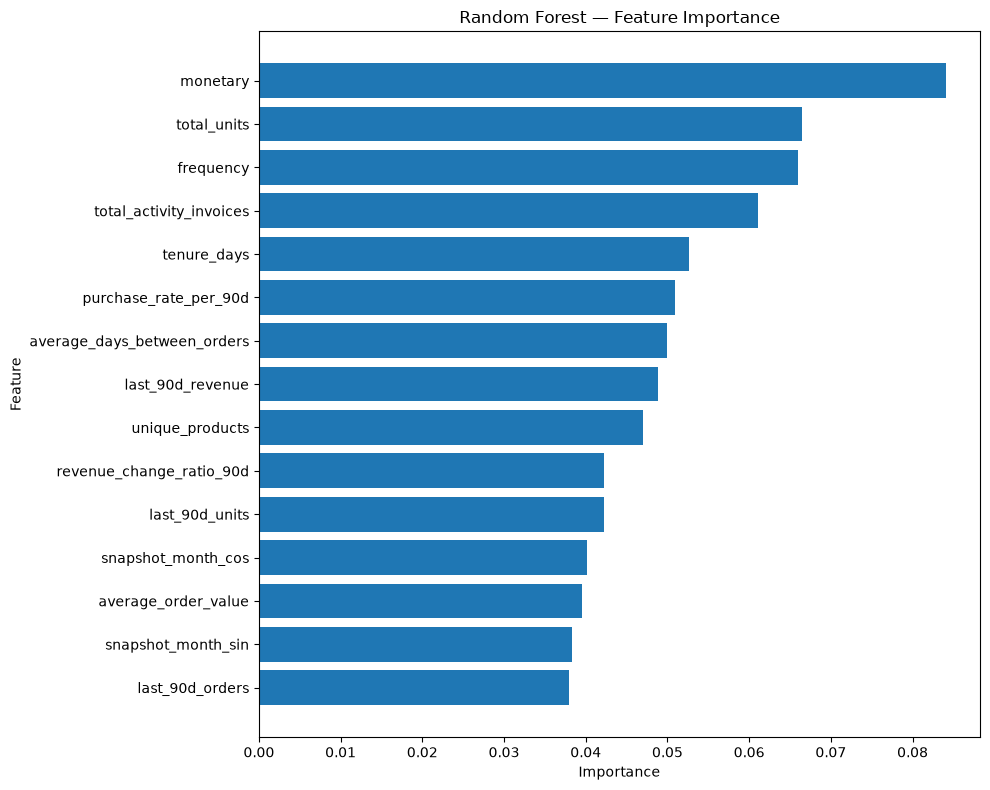

In [119]:
top_importance = (
    feature_importance
    .head(15)
    .sort_values(
        "importance",
        ascending=True,
    )
)


plt.figure(figsize=(10, 8))

plt.barh(
    top_importance["feature"],
    top_importance["importance"],
)

plt.title(
    "Random Forest — Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "churn_feature_importance.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [120]:
test_scored = test_data[
    [
        "customer_id",
        "snapshot_date",
        "recency_days",
        "frequency",
        "monetary",
        "average_order_value",
        "return_invoice_rate",
        "churn_90d",
    ]
].copy()


test_scored["churn_probability"] = (
    test_probabilities
)


test_scored["predicted_churn"] = (
    test_predictions
)


test_scored = test_scored.sort_values(
    "churn_probability",
    ascending=False,
).reset_index(drop=True)


display(
    test_scored.head(25)
)

,customer_id,snapshot_date,recency_days,frequency,monetary,average_order_value,return_invoice_rate,churn_90d,churn_probability,predicted_churn
0,17024,2011-09-01,57,1,31.2500,31.2500,0.0000,0,0.8597,1
1,13120,2011-09-01,138,1,30.6000,30.6000,0.0000,1,0.8449,1
2,17060,2011-09-01,166,1,234.2400,234.2400,0.0000,1,0.8430,1
3,13391,2011-09-01,103,1,59.8000,59.8000,0.0000,1,0.8346,1
4,18010,2011-09-01,156,1,174.8000,174.8000,0.0000,1,0.8318,1
5,17102,2011-09-01,161,1,25.5000,25.5000,0.0000,1,0.8274,1
6,15206,2011-09-01,45,2,53.1000,26.5500,0.0000,0,0.8260,1
7,16093,2011-09-01,6,1,17.0000,17.0000,0.0000,1,0.8214,1
8,13229,2011-09-01,125,1,160.9500,160.9500,0.0000,1,0.8208,1
9,16849,2011-09-01,86,1,124.5700,124.5700,0.0000,1,0.8204,1


In [121]:
MODEL_PATH = (
    MODELS_DIR
    / "churn_random_forest.joblib"
)


joblib.dump(
    {
        "model": final_model,
        "features": FEATURE_COLUMNS,
        "threshold": SELECTED_THRESHOLD,
        "prediction_horizon_days": 90,
    },
    MODEL_PATH,
)


feature_importance.to_csv(
    REPORTS_DIR
    / "churn_feature_importance.csv",
    index=False,
)


test_scored.to_csv(
    REPORTS_DIR
    / "churn_test_predictions.csv",
    index=False,
)


test_lift_results.to_csv(
    REPORTS_DIR
    / "churn_test_lift.csv",
    index=False,
)


test_metrics_dict = {
    str(key): float(value)
    for key, value
    in test_metrics.items()
}


(
    REPORTS_DIR
    / "churn_final_test_metrics.json"
).write_text(
    json.dumps(
        test_metrics_dict,
        indent=2,
    ),
    encoding="utf-8",
)


print("=" * 65)
print("Churn modeling pipeline completed successfully")
print("=" * 65)

print(f"Final model:       {SELECTED_MODEL_NAME}")
print(f"Threshold:         {SELECTED_THRESHOLD:.2f}")
print(
    f"Test ROC-AUC:      "
    f"{test_metrics['ROC-AUC']:.4f}"
)
print(
    f"Test PR-AUC:       "
    f"{test_metrics['PR-AUC']:.4f}"
)
print(
    f"Test F1:           "
    f"{test_metrics['F1']:.4f}"
)
print(f"Saved model:       {MODEL_PATH}")

Churn modeling pipeline completed successfully
Final model:       Random Forest
Threshold:         0.31
Test ROC-AUC:      0.7569
Test PR-AUC:       0.6306
Test F1:           0.6545
Saved model:       c:\Users\omary\Documents\VS Code\customer-intelligence-analytics\models\churn_random_forest.joblib


## Final Churn Modeling Findings

### The model generalizes successfully to a future time period

The final Random Forest model was evaluated on the September 2011 snapshot,
which was kept separate from model and threshold selection.

It achieved:

- ROC-AUC: **0.7569**
- PR-AUC: **0.6306**
- Brier Score: **0.1938**
- F1 Score: **0.6545**

The ROC-AUC remains close to the validation result of 0.7692, indicating that
the model preserves useful ranking ability when applied to a later time period.

### Customer ranking is particularly valuable for retention targeting

The strongest business value of the churn model is its ability to prioritize
customers.

Among the top 5% of customers ranked by predicted churn probability, the
observed churn rate is approximately 74.1%, compared with a test-period
baseline of only 39.3%.

This corresponds to a lift of approximately **1.89x**.

The top 10% of customers achieve a churn rate of 71.6% and a lift of
approximately **1.82x**, while targeting the top 20% captures approximately
34.4% of all churners.

These results demonstrate that the model can meaningfully concentrate
retention efforts on customers who are substantially more likely to become
inactive.

### A fixed classification threshold should not directly determine retention spending

The validation-selected threshold of 0.31 produces high recall on the test
period (89.2%) but predicts approximately 67.8% of customers as churners,
compared with an observed churn rate of 39.3%.

This illustrates an important distinction between predictive classification
and business decision-making.

The threshold remains useful as a classification operating point, but the
final retention system should not automatically offer incentives to every
customer above this threshold.

Instead, retention decisions will combine predicted churn probability with
customer value, expected retention benefit, intervention cost, and available
campaign capacity.

### Customer history and value are major predictive signals

The most influential Random Forest features include monetary value, total
units purchased, purchase frequency, total customer activity, relationship
tenure, purchase rate, time between purchases, recent revenue, and product
breadth.

Seasonal features also contribute to the model, supporting the temporal
patterns identified during churn-dataset analysis.

Feature importance should be interpreted as predictive contribution rather
than causality, particularly because several customer-behavior variables are
correlated.

### The churn model is ready to be combined with customer value

Churn probability alone answers:

> Who is likely to stop purchasing?

The next stage will estimate customer lifetime value so that the final decision
system can answer the more important business question:

> Which at-risk customers are valuable enough to justify retention investment?